In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns

In [2]:
""" COMBINE ALL TSV FILES INTO ONE MEGA FILE!!!"""
dataset_path = '/home/kevin/Desktop/gut_microbiome/dataset/mgnify_gut/taxonomy_abundances'
# Path to the TSV files (update this to your actual directory)
ts_files = glob.glob(f"{dataset_path}/*.tsv")

# Initialize an empty list to store transposed dataframes
dataframes = []

for file in ts_files:
    df = pd.read_csv(file, sep='\t', index_col=0)  # Read TSV, using first column as index
    df = df.T  # Transpose to make samples as rows and species as columns
    df['Sample'] = file  # Add a column to track the sample name (filename)
    dataframes.append(df)

# Combine all dataframes
combined_df = pd.concat(dataframes, axis=0)

# Reset index and rename for clarity
combined_df = combined_df.reset_index().rename(columns={'index': 'Sample'})

# Save the combined dataframe to a new TSV file
combined_df.to_csv(f"{dataset_path}/combined_taxonomy_abundance.csv", sep=',', index=False)

In [8]:
# load csv
file_path = "/home/kevin/Desktop/gut_microbiome/dataset/mgnify_gut/taxonomy_abundances/combined_taxonomy_abundance.csv"
df = pd.read_csv(file_path)

In [9]:
df.columns

Index(['Sample',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter;s__Methanobrevibacter_smithii',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanomicrobia;o__Methanomicrobiales',
       'sk__Archaea;k__;p__Euryarchaeota;c__Thermoplasmata;o__Methanomassiliicoccales',
       'sk__Archaea;k__;p__Euryarchaeota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomassiliicoccaceae;g__Candidatus_Methanoplasma',
       'sk__Bacteria', 'sk__Bacteria;k__;p__Actinobacteria',
       'sk__Bacteria;k__;p__Actinobacteria;c__Acidimicrobiia;o__Acidimicrobiales;f__Ilumatobacteraceae',
       'sk__Bacteria;k__;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces',
       ...
       'sk__Bacteria;k__;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcac

/tmp/ipykernel_13266/3100139980.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bacteria_presence.index, y=bacteria_presence.values, palette='viridis')


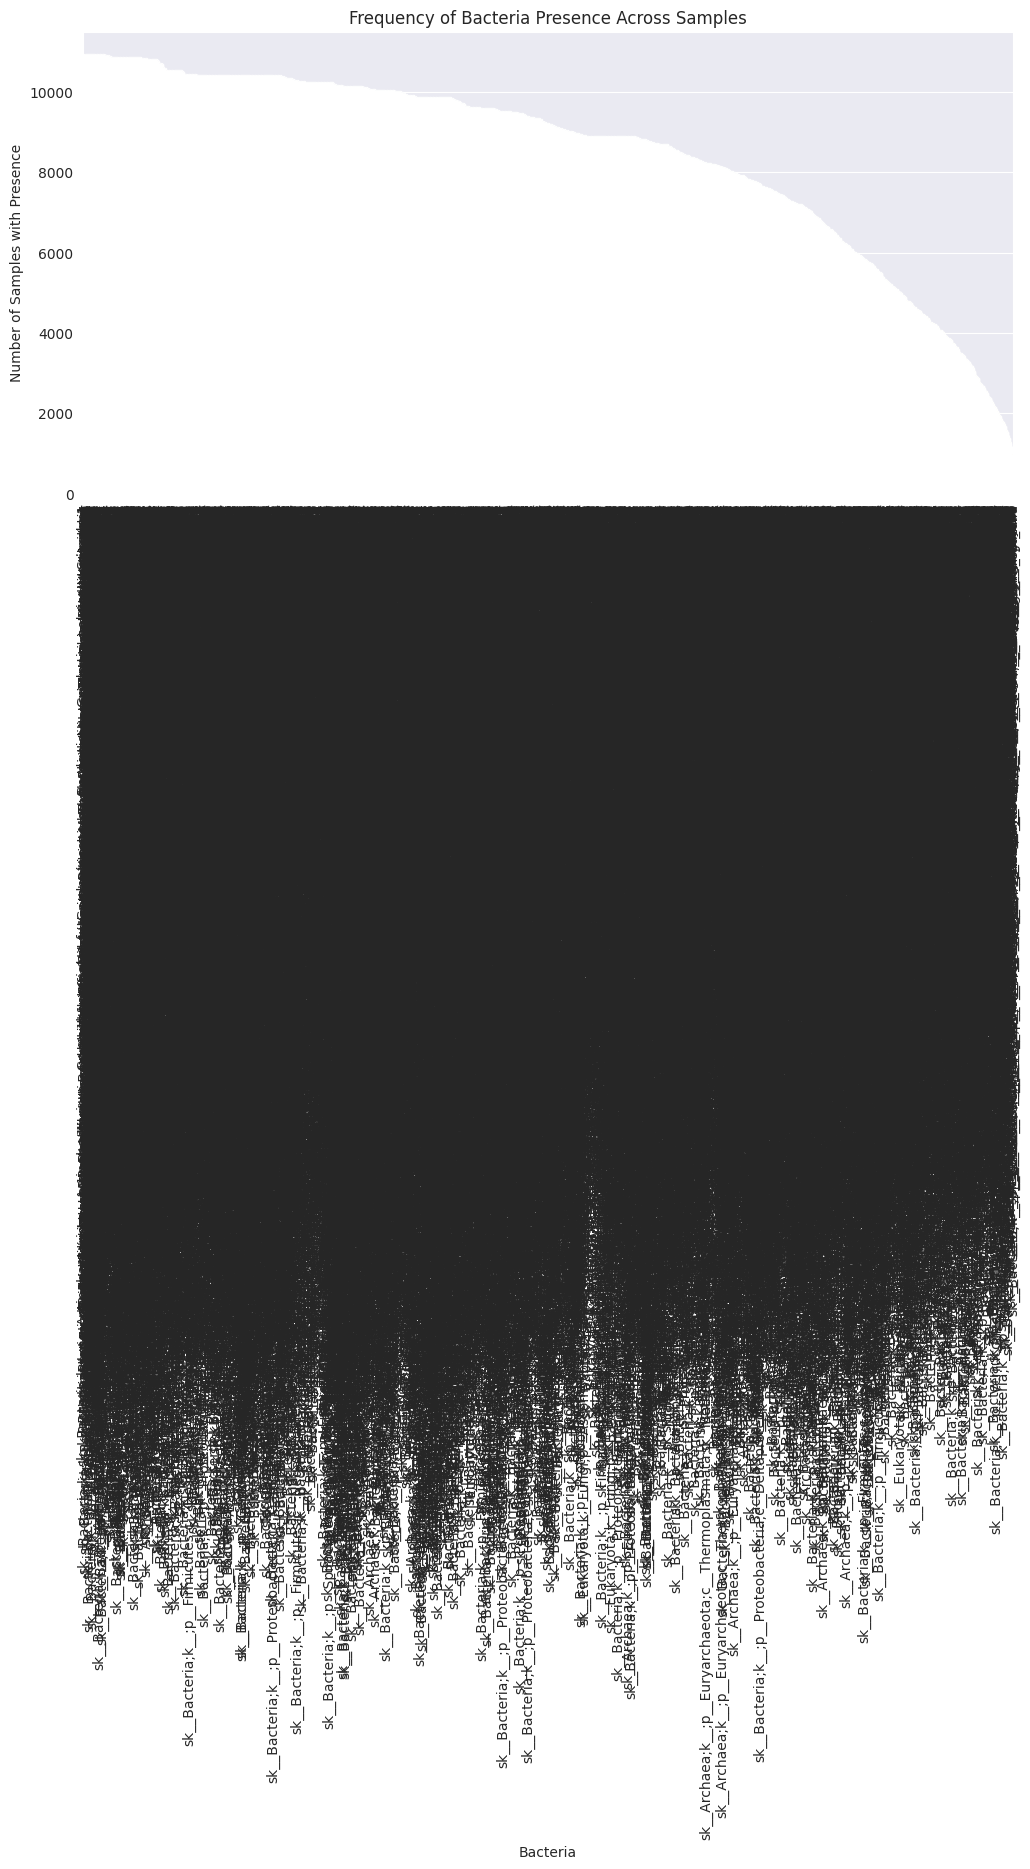

In [13]:
# Count the number of nonzero occurrences per bacteria (column)
bacteria_presence = (df != 0).sum()

# Sort from most frequent to least frequent
bacteria_presence = bacteria_presence.sort_values(ascending=False)
# drop first one cuz sample label
bacteria_presence = bacteria_presence[1:]
# Plot the data
plt.figure(figsize=(12, 6))
sns.barplot(x=bacteria_presence.index, y=bacteria_presence.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Bacteria')
plt.ylabel('Number of Samples with Presence')
plt.title('Frequency of Bacteria Presence Across Samples')
plt.show()

In [11]:
bacteria_presence

Sample.1                                                                                                                                                  10945
sk__Bacteria;k__;p__Actinobacteria;c__Actinobacteria;o__Corynebacteriales;f__Gordoniaceae;g__Gordonia;s__Gordonia_polyisoprenivorans                      10941
sk__Bacteria;k__;p__Proteobacteria;c__Betaproteobacteria;o__Nitrosomonadales;f__Sterolibacteriaceae;g__Methyloversatilis;s__Methyloversatilis_sp._cd-1    10941
sk__Bacteria;k__;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Phyllobacteriaceae;g__Phyllobacterium                                         10939
sk__Bacteria;k__;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Odoribacteraceae;g__Butyricimonas;s__Butyricimonas_paravirosa                        10939
                                                                                                                                                          ...  
sk__Bacteria;k__;p__Actinobacteria;c__Ac

Number of bacteria species covering 97% of data: 3105


/tmp/ipykernel_13266/3077904894.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=smaller_table.index, y=smaller_table.values, palette='viridis')


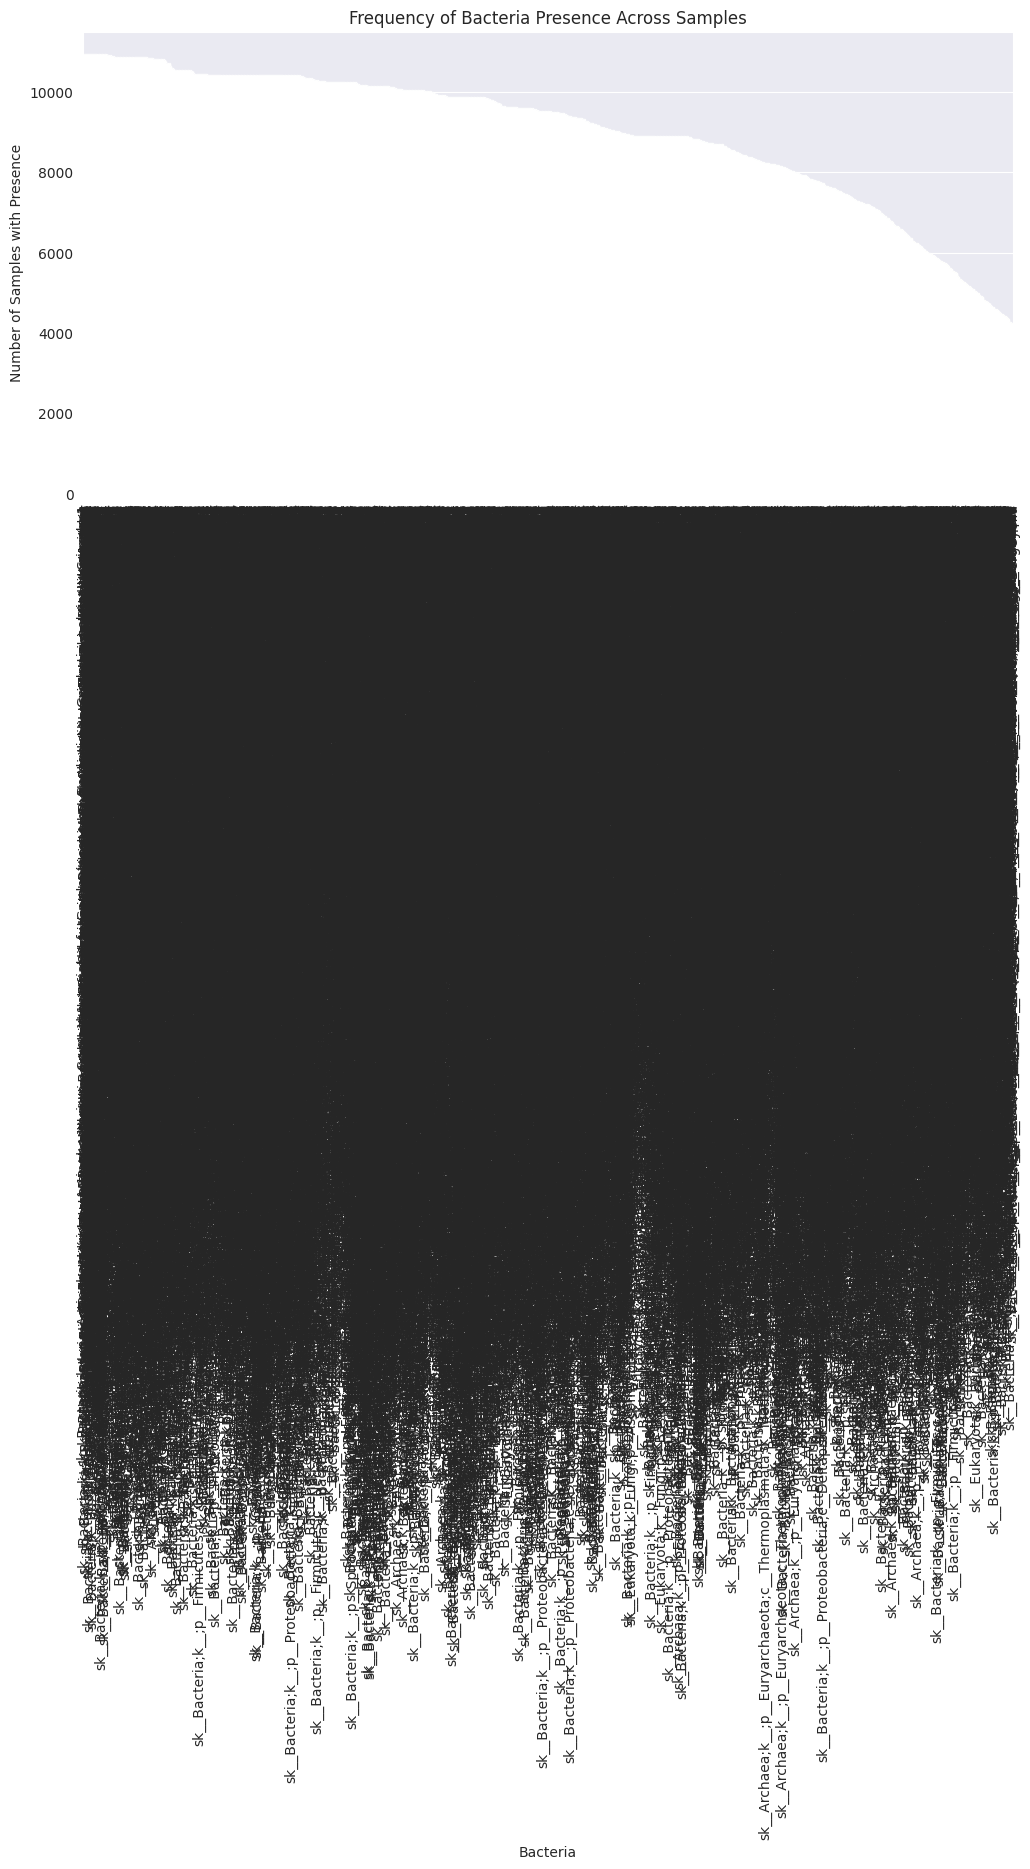

In [14]:
# Compute cumulative sum and find the number of species covering 97% of occurrences
cumulative_sum = bacteria_presence.cumsum()
total_sum = bacteria_presence.sum()
top_97_species = (cumulative_sum / total_sum <= 0.97).sum()
print(f'Number of bacteria species covering 97% of data: {top_97_species}')

# Plot the data
smaller_table = bacteria_presence[:top_97_species]
plt.figure(figsize=(12, 6))
sns.barplot(x=smaller_table.index, y=smaller_table.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Bacteria')
plt.ylabel('Number of Samples with Presence')
plt.title('Frequency of Bacteria Presence Across Samples')
plt.show()

In [16]:
df_small = df[bacteria_presence[:512].index]
total_cells = df_small.size
nonzero_cells = (df_small != 0).sum().sum()
table_populated_percentage = (nonzero_cells / total_cells) * 100
print(f'Percentage of the entire table populated with data: {table_populated_percentage:.2f}%')

Percentage of the entire table populated with data: 97.73%


In [17]:
df.columns

Index(['Sample',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter;s__Methanobrevibacter_smithii',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanomicrobia;o__Methanomicrobiales',
       'sk__Archaea;k__;p__Euryarchaeota;c__Thermoplasmata;o__Methanomassiliicoccales',
       'sk__Archaea;k__;p__Euryarchaeota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomassiliicoccaceae;g__Candidatus_Methanoplasma',
       'sk__Bacteria', 'sk__Bacteria;k__;p__Actinobacteria',
       'sk__Bacteria;k__;p__Actinobacteria;c__Acidimicrobiia;o__Acidimicrobiales;f__Ilumatobacteraceae',
       'sk__Bacteria;k__;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces',
       ...
       'sk__Bacteria;k__;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcac

In [19]:
(df.columns == 'sk__Bacteria;k__;p__Tenericutes;c__Mollicutes;o__Anaeroplasmatales;f__Anaeroplasmataceae;g__Anaeroplasma').sum()

np.int64(1)